In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

In [5]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [6]:
url = "https://quotes.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)


Status Code: 200


In [7]:
soup = BeautifulSoup(
    response.text,
    "html.parser"
)


In [8]:
quotes = soup.find_all(
    "span",
    class_="text"
)

text_data = []

for quote in quotes:

    text = quote.get_text(
        strip=True
    )

    text_data.append(text)


print("Total extracted texts:", len(text_data))


Total extracted texts: 10


In [9]:
full_text = " ".join(text_data)

In [10]:
lower_text = full_text.lower()

In [11]:
clean_text = re.sub(
    r"[^a-zA-Z\s]",
    "",
    lower_text
)

In [12]:
words = word_tokenize(
    clean_text
)


In [13]:
stop_words = set(
    stopwords.words("english")
)

filtered_words = [
    word
    for word in words
    if word not in stop_words
]

In [14]:
word_frequency = Counter(
    filtered_words
)


print("\nMost Common Words:")

for word, count in word_frequency.most_common(10):

    print(
        word,
        ":",
        count
    )



Most Common Words:
thinking : 2
without : 2
ways : 2
though : 2
miracle : 2
better : 2
absolutely : 2
become : 2
man : 2
like : 2


In [15]:
df = pd.DataFrame({
    "Word": list(
        word_frequency.keys()
    ),
    "Frequency": list(
        word_frequency.values()
    )
})


df = df.sort_values(
    by="Frequency",
    ascending=False
)


In [16]:
df.to_csv(
    "text_analysis.csv",
    index=False
)

In [17]:
print("\nText Statistics")

print(
    "Characters:",
    len(full_text)
)

print(
    "Total words:",
    len(words)
)

print(
    "Unique words:",
    len(set(words))
)

print(
    "Words after preprocessing:",
    len(filtered_words)
)


Text Statistics
Characters: 904
Total words: 171
Unique words: 98
Words after preprocessing: 75


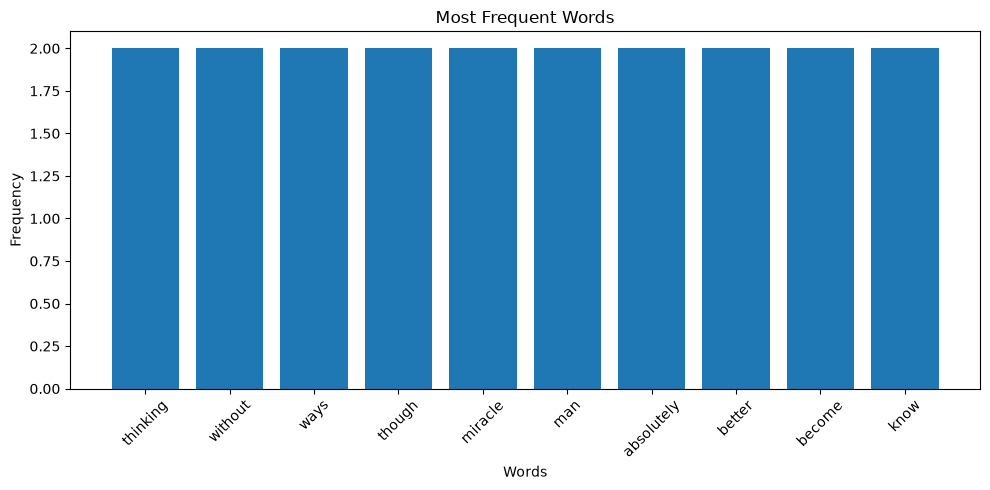

In [18]:
top_words = df.head(10)

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    top_words["Word"],
    top_words["Frequency"]
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.title(
    "Most Frequent Words"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


In [19]:
plt.show()